# Find MSLP analogues of ERA5 event 

- selects desired precipitation event
- searches for analogues in ERA5 dataset
- searches for analogues in CRCM5 Large Ensemble

### Packages and Directories

In [172]:
# --- Imports ---
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import dask
from dask.distributed import Client, LocalCluster
from scipy.interpolate import griddata
import calendar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Custom Functions ---
# sys.path.append('/home/portal/script/python/precip_Cristina/')                    # tintin
sys.path.append('/home/alice/Desktop/work/git/myISACcode/python/precip_Cristina')   # alice
import functions_analogues_PrMax as fanPM
import functions_analogues_LUCAFAMOSS as fan

In [173]:
# Define directories for data and figures
# # tintin
# CERRA_dir = '/work_big/users/clima/portal/CERRA-Land/'
# ERA5_dir = '/work_big/users/clima/portal/ERA5/'
# CRCM5_dir = '/work_big/users/clima/portal/CRCM5-LE/'
# fig_dir = '/home/portal/figures/case-studies_byNode/'

# alice
CERRA_dir = '/media/alice/Crucial X9/portal/data_CNR/CERRA/'
ERA5_dir = '/media/alice/Crucial X9/portal/data_CNR/ERA5/'
CRCM5_dir = '/media/alice/Crucial X9/portal/data_CNR/CRCM5-LE/'
fig_dir = '/home/alice/Desktop/CNR/ENCIRCLE/materiale_alice/figures/analogues/'
pslmin_dir = './analogue_data/psl_min/'

### Identifies event in time and space

In [174]:
# Event selection
lselect = 'alert-regions'  # 'Italy' or 'wide-region' or 'alert-regions'
no_node = 6
no_event = 19
# Upload the data
if lselect == 'wide-region':
    df_events = pd.read_excel(CERRA_dir+'events_on_wide_regions.xlsx', sheet_name=no_node-1)
elif lselect == 'alert-regions':
    df_events = pd.read_excel(CERRA_dir+'events_cum_on_above99_alertregions_CERRA.xlsx', sheet_name=no_node-1)
elif lselect == 'Italy':
    df_events = pd.read_excel(CERRA_dir+'events_on_Italy.xlsx', sheet_name=no_node-1)
time_event = df_events['Time'].iloc[no_event-1] + pd.Timedelta('12h')
doy_event =  time_event.timetuple().tm_yday
# Define lon-lat box of event
box_event = fanPM.box_event_PrMax_alertregions(no_node,no_event)

# Event information
print('Event time:', time_event)
print('Event DOY:', doy_event)
print('Event box:', box_event)

Event time: 1996-10-08 18:00:00
Event DOY: 282
Event box: [2, 20, 33, 48]


In [175]:
# Defines the months for analogue selection
month_event = time_event.month
months_sel = [month_event-1, month_event, month_event+1]
# Get the month names
month_names = [calendar.month_abbr[month] for month in months_sel]
# Extract the initials
str_months = ''.join([name[0] for name in month_names])

# Months for analogue selection
print('Season (selection of 3 months) for analogue search:', str_months)

Season (selection of 3 months) for analogue search: SON


### Upload event data in ERA5 (anom & clim)

In [176]:
# Upload event mslp data
dmslp_event = fanPM.load_ERA5_data('mslp', 'daily', time_event, box_event, l_anom=True, data_dir=ERA5_dir+'mslp/')
mslp_clim = fanPM.load_ERA5_clim('mslp', doy_event, box_event, l_smoothing=True, data_dir=ERA5_dir+'mslp/climatology/')
# Upload event z500 data
dz500_event = fanPM.load_ERA5_data('z500', 'daily', time_event, box_event, l_anom=True, data_dir=ERA5_dir+'z500/')
z500_clim = fanPM.load_ERA5_clim('z500', doy_event, box_event, l_smoothing=True, data_dir=ERA5_dir+'z500/climatology/')

#### Plot event field

/tmp/ipykernel_52067/1231503503.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


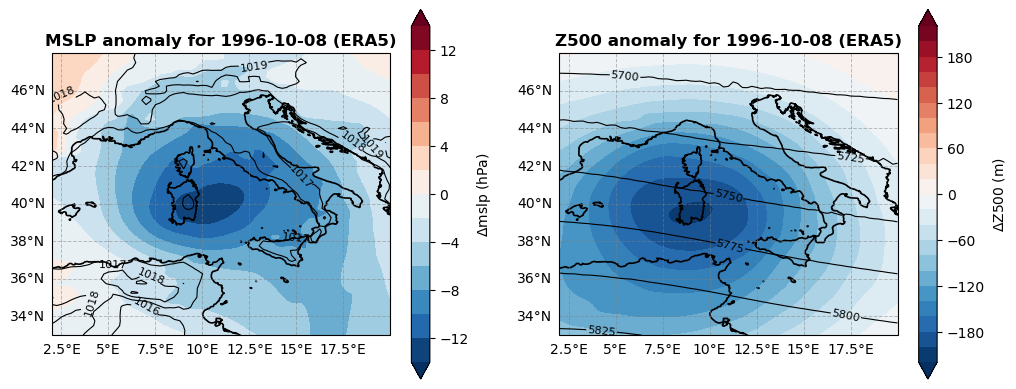

In [177]:
# Plot event
fig, ax = plt.subplots(
    nrows=1, ncols=2, figsize=(12, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
    )
fanPM.plot_anom_event(ax[0], "mslp", dmslp_event.longitude, dmslp_event.latitude, dmslp_event.values, mslp_clim, 
                      "MSLP anomaly for "+str(time_event)[:10]+" (ERA5)")
fanPM.plot_anom_event(ax[1], "z500", dz500_event.lon, dz500_event.lat, dz500_event.values, z500_clim, 
                      "Z500 anomaly for "+str(time_event)[:10]+" (ERA5)")
fig.show()
fig.savefig(fig_dir+'mslp_z500_node'+str(no_node)+'_extreme'+str(no_event)+'-alertregions_box-analogues.png')

#### Select ERA5 event data to event box at 0.5 resolution

In [178]:
dmslp_event_regridded = fanPM.regrid_with_xesmf(dmslp_event, box_event, resolution=0.5)
mslp_clim_regridded = fanPM.regrid_with_xesmf(mslp_clim, box_event, resolution=0.5)
dz500_event_regridded = fanPM.regrid_with_xesmf(dz500_event, box_event, resolution=0.5)
z500_clim_regridded = fanPM.regrid_with_xesmf(z500_clim, box_event, resolution=0.5)

/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


## Find analogues in ERA5

### Parameters of data selection

In [179]:
# Variable
var_analogues = ['mslp','z500'] # ['mslp','z500']
var_names = ['msl','z'] # ['msl','z']
var_factors = [0.01, 1/9.81]  # [0.01, 1/9.81] to convert from Pa to hPa and from geopot to geopot height
str_vars = '-'.join(var_analogues)+'-std'
print('Variables for analogue search:', str_vars)
# Time
year_range = [2004, 2023]
years_sel = np.arange(year_range[0], year_range[1]+1)

Variables for analogue search: mslp-z500-std


### Load and preprocess data for analogue search

In [180]:
# Define the file pattern for loading analogue data
for iv, var in enumerate(var_analogues):
    if var=='z500':
        file_pattern = ERA5_dir + var +"/res05/ERA5_"+var+"_NH_daily_*_anom_detrended_regridded-to-CRCM5.nc"
    else:
        file_pattern = ERA5_dir + var +"/res05/ERA5_"+var+"_NH_daily_*_anom_regridded-to-CRCM5.nc"
    anom_tmp = xr.open_mfdataset(file_pattern, combine='by_coords', parallel=True)[var_names[iv]] * var_factors[iv]
    anom_tmp = anom_tmp.sel(time=anom_tmp.time.dt.month.isin(months_sel))
    anom_tmp = anom_tmp.sel(time=anom_tmp.time.dt.year.isin(years_sel))

    # Define and select lon lat masks (specific of each event)
    lon_mask, lat_mask = fanPM.lonlat_mask(anom_tmp.lon.values, anom_tmp.lat.values, box_event)
    mask = lat_mask[:, np.newaxis] & lon_mask
    mask_xr = xr.DataArray(
        mask,
        dims=["lat", "lon"],
        coords={"lat": anom_tmp.lat, "lon": anom_tmp.lon},
    )
    
    # Apply mask to the dataset
    vars()[f'd{var}_sel'] = anom_tmp.where(mask_xr, drop=True).copy()

### Quantile selection

In [181]:
# Quantile
qtl = 0.99
# Fix number of analogues based on the quantile
n_analogues = 18 # corresponds to int(np.round(len(dmslp_sel.time) * (1-qtl)))
print('Number of analogues to be selected:', n_analogues)
# Minimum spacing between analogues
analogue_spacing = 7 # days

Number of analogues to be selected: 18


### Compute Euclidean distance from event

In [182]:
# Compute standardised euclidean distance from the event
dist_per_var = {}
dist = None
for var in var_analogues:
    f_anom = vars()[f'd{var}_sel'].squeeze()
    f_anom_event = vars()[f'd{var}_event_regridded'].squeeze()
    # standardise anomaly maps
    f_std = f_anom.std(dim='time')
    f_anom_std = f_anom / f_std
    f_anom_event_std = f_anom_event / f_std
    # compute euclidean distance
    dist_per_var[var] = fan.function_distance(f_anom_event_std, f_anom_std, nan_version=True)
    if dist is None:
        dist = dist_per_var[var]**2
    else:
        dist += dist_per_var[var]**2
dist = np.sqrt(dist)
print(dist[:100])

[ 51.456028  60.459454  87.4608   103.0197    88.245316  72.75953
  78.76704   88.02548   98.27398   98.62925  100.67787   87.33133
  75.92934   70.17134   67.77527   62.45851   58.408615  57.773693
  50.579685  61.39682   75.32768   73.04345   65.15019   47.004135
  34.265694  35.206326  44.89903   62.601135  64.75831   79.47606
  94.49226   98.28221   98.77716   95.78558   92.25017   83.93007
  75.17406   71.71426   69.62736   62.567947  54.0472    52.240025
  43.920128  39.350388  47.19774   58.02833   61.692497  67.41687
  76.12844   86.449135  89.66073   99.9872   103.84565  100.70981
  83.52138   49.435257  40.81223   58.733974  66.17757   62.18291
  59.279835  61.568985  51.418594  59.80056   69.15289   71.11231
  61.68339   40.35214   53.03142   49.67142   48.73776   37.050587
  41.766483  52.782585  58.529694  35.52523   71.245674 109.43356
 113.12744   88.14156   87.90548  107.99299  131.6779   112.08624
 105.39864  116.01269  130.89397  110.132744  93.232216  78.2303
  59.18

### Analogue selection

1. Identify a large pool of analogues using qtl_0sel

2. Exclude analogues within ±7 days of their associated event

3. Select analogues with >=7-day spacing between them (keeping best n_analogues, i.e. 1st percentile of days after analogue filtering)

4. Average selected analogues, if at least n_analogues have been selected

In [183]:
# First search of n_analogues
factor_0sel = 2
qtl_0sel = 1 - ((1 - qtl) * factor_0sel)  # First selection of the quantile, for extracting a total of n_analogues
l_0sel = True  # Flag for selection of analogues

while l_0sel:
    # Compute log-transformed distance
    logdist = np.log(1 / dist)
    # Threshold at given quantile 0sel
    thresh_0sel = np.percentile(logdist, qtl_0sel * 100, axis=0)
    mask_analogues = logdist >= thresh_0sel
    
    # Event time, all times and required time spacing
    all_times = vars()[f'd{var_analogues[0]}_sel'].time.values
    event_time = vars()[f'd{var_analogues[0]}_event'].time.values
    
    # Exclude analogue times within ±7 days of their associated event
    time_diff = np.abs((all_times - event_time).astype('timedelta64[D]').astype(int))
    mask_analogues &= np.array(time_diff) >= analogue_spacing  # update mask to exclude times too close to the event
    indices_analogues = np.where(mask_analogues)[0]  # indices of all valid analogue times
    
    # Filter analogues based on the mask and logdist, ensuring they are spaced correctly (analogue_spacing days apart)
    indices_filtered_analogues = fan.timefilter_analogues(indices_analogues, logdist, all_times, analogue_spacing)

    if len(indices_filtered_analogues)>=n_analogues:
        indices_filtered_analogues = indices_filtered_analogues[:n_analogues]  # Select the first n_analogues (corresponding to the quantile qtl)
        l_0sel = False
        print("Selection completed using pool data from quantile", qtl_0sel)
    else:
        factor_0sel +=1
        qtl_0sel = 1 - ((1 - qtl) * factor_0sel)
    
# Save distance and times of selected analogues
listdistances = dist[indices_filtered_analogues]
listtimes = all_times[indices_filtered_analogues]

# Select and average
thresh = dist[indices_filtered_analogues[-1]]
print(f"Selected analogues with distance threshold: {thresh}")
for var in var_analogues:
    anom_analogues = vars()[f'd{var}_sel'].isel(time=indices_filtered_analogues) 
    anom_analogues_mean = anom_analogues.mean(dim='time')
    vars()[f'd{var}_analogues'] = anom_analogues
    vars()[f'd{var}_analogues_mean'] = anom_analogues_mean

Selection completed using pool data from quantile 0.98
Selected analogues with distance threshold: 32.023231506347656


In [184]:
# Print the selected analogue times
print("Selected "+str(n_analogues)+" analogue times:\n", all_times[indices_filtered_analogues])
print('Threshold distance', thresh)

Selected 18 analogue times:
 [cftime.DatetimeNoLeap(2010, 11, 2, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2017, 11, 7, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2006, 9, 16, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2008, 9, 14, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2018, 10, 2, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2019, 11, 17, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2012, 9, 14, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2022, 11, 29, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 10, 10, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2022, 11, 20, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2010, 10, 14, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2021, 11, 22, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2009, 9, 14, 9, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2006, 9, 26, 9, 0, 0, 0, has_year_zero=True)
 cftime.Datet

#### Optional: climatology from ERA5 analogue selection

In [185]:
for var in var_analogues:
    doy_analogues = vars()[f'd{var}_analogues']['time'].dt.dayofyear # day-of-year (DOY) from each analogue date
    clim_analogues_sum = None # Initialize sum of climatology fields
    
    # Loop through each DOY and accumulate corresponding climatology
    for i, doy in enumerate(doy_analogues):
        # Load climatology for the specific DOY
        clim_day = fanPM.load_ERA5_clim(var, doy.item(), box_event, l_smoothing=True, data_dir=ERA5_dir+var+'/climatology/').squeeze()
    
        # Accumulate climatology
        if i == 0:
            clim_analogues_sum = clim_day
        else:
            clim_analogues_sum += clim_day
    
    # Compute average climatology over all analogue dates
    clim_analogues = clim_analogues_sum / len(doy_analogues)
    clim_analogues_regridded = fanPM.regrid_with_xesmf(clim_analogues, box_event, resolution=0.5) # Regrid to the desired resolution
    vars()[f'{var}_clim_analogues'] = clim_analogues_regridded
    

/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/alice/anaconda3/envs/xesmf_env/lib/python3.13/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


#### Compute mean on ERA5 analogues

/tmp/ipykernel_52067/3408020641.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


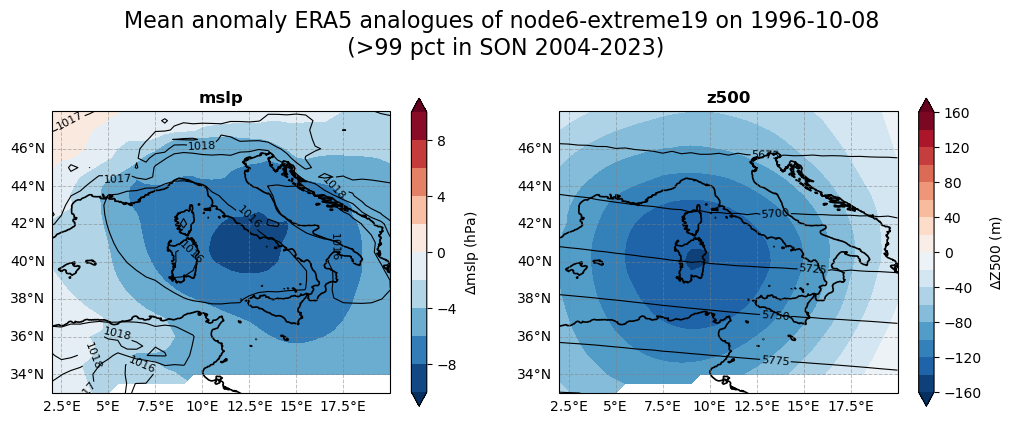

In [186]:
# Plot analogue mean
fig, ax = plt.subplots(
    nrows=1, ncols=len(var_analogues), figsize=(6*len(var_analogues), 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
    )
fig.suptitle(f'Mean anomaly ERA5 analogues of node{no_node}-extreme{no_event} on {str(time_event)[:10]}\n (>{str(int(qtl*100))} pct in {str_months} {str(year_range[0])}-{str(year_range[1])})', fontsize=16)
for i, var in enumerate(var_analogues):
    if len(var_analogues)>1:
        axi = ax[i]
    else:
        axi = ax
    analogues_anom_mean = vars()[f'd{var}_analogues_mean'].squeeze()
    analogues_clim = vars()[f'{var}_clim_analogues'].squeeze()
    fanPM.plot_anom_event(axi, var, analogues_anom_mean.lon, analogues_anom_mean.lat, analogues_anom_mean.values, analogues_clim,
                          f"{var}")
fig.show()
fig.savefig(fig_dir+'analogues-'+str_vars+'_node'+str(no_node)+'_extreme'+str(no_event)+'-alertregions_mean_'+str(int(qtl*100))+'pct_'+str_months+'_'+str(year_range[0])+'-'+str(year_range[1])+'_ERA5.png')

### Compute pmin (abs and from boxmean)

In [187]:
# Compute pmin (abs and from boxmean)
pmin = dmslp_analogues.min(dim=['lon', 'lat'], skipna=True)
pmean = dmslp_analogues.mean(dim=['lon', 'lat'], skipna=True)
pmin_from_boxmean = (dmslp_analogues - pmean).min(dim=['lon', 'lat'], skipna=True)
# Save pmin values
pmin.to_netcdf(f"{pslmin_dir}analogues-{str_vars}_min-mslp_node{no_node}-extreme{no_event}-alertregions_{int(qtl*100)}pct_{year_range[0]}-{year_range[1]}_ERA5.nc")
pmin_from_boxmean.to_netcdf(f"{pslmin_dir}analogues-{str_vars}_min-from-boxmean-mslp_node{no_node}-extreme{no_event}-alertregions_{int(qtl*100)}pct_{year_range[0]}-{year_range[1]}_ERA5.nc")

In [188]:
print(np.mean(pmin.values))
print(np.mean(pmin_from_boxmean.values))

-10.63683
-6.006525
